# Boost Factor Module Test

Test the boost factor implementation.

Reference: McClintock et al. 2019 (arXiv:1805.00039)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Import the boost factor model from our module
from applyBoostFactor import boost_factor_model

## 1. Test Boost Factor Model
Model: NFW-like profile with parameters:
- `rs`: scale radius (Mpc/h)
- `b0`: amplitude

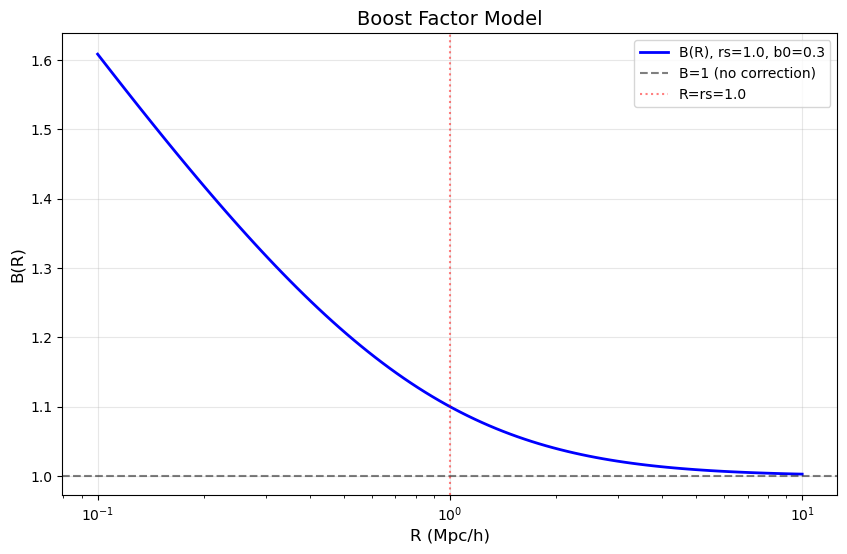

B >= 1 everywhere: True
B at R=rs: 1.1000
Expected (b0+3)/3: 1.1000


In [2]:
# Test parameters
rs = 1.0  # Mpc/h
b0 = 0.3

# Test radii
R = np.logspace(-1, 1, 100)  # 0.1 to 10 Mpc/h

# Compute boost factor
B = boost_factor_model(R, rs, b0)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(R, B, 'b-', lw=2, label=f'B(R), rs={rs}, b0={b0}')
plt.axhline(y=1, color='k', linestyle='--', alpha=0.5, label='B=1 (no correction)')
plt.axvline(x=rs, color='r', linestyle=':', alpha=0.5, label=f'R=rs={rs}')
plt.xlabel('R (Mpc/h)', fontsize=12)
plt.ylabel('B(R)', fontsize=12)
plt.title('Boost Factor Model', fontsize=14)
plt.xscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"B >= 1 everywhere: {np.all(B >= 1)}")
print(f"B at R=rs: {boost_factor_model(np.array([rs]), rs, b0)[0]:.4f}")
print(f"Expected (b0+3)/3: {(b0+3)/3:.4f}")

## 2. Test Different Parameters

Explore how rs and b0 affect the boost factor.

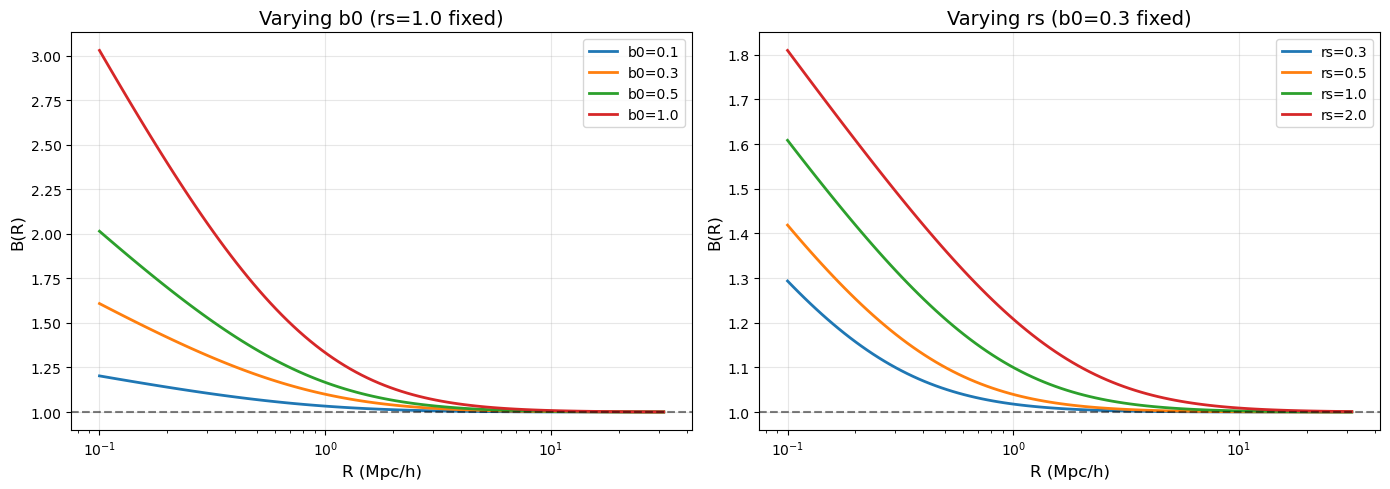

In [3]:
R = np.logspace(-1, 1.5, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vary b0
ax = axes[0]
rs_fixed = 1.0
for b0 in [0.1, 0.3, 0.5, 1.0]:
    B = boost_factor_model(R, rs_fixed, b0)
    ax.plot(R, B, lw=2, label=f'b0={b0}')
ax.axhline(y=1, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel('R (Mpc/h)', fontsize=12)
ax.set_ylabel('B(R)', fontsize=12)
ax.set_title(f'Varying b0 (rs={rs_fixed} fixed)', fontsize=14)
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

# Vary rs
ax = axes[1]
b0_fixed = 0.3
for rs in [0.3, 0.5, 1.0, 2.0]:
    B = boost_factor_model(R, rs, b0_fixed)
    ax.plot(R, B, lw=2, label=f'rs={rs}')
ax.axhline(y=1, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel('R (Mpc/h)', fontsize=12)
ax.set_ylabel('B(R)', fontsize=12)
ax.set_title(f'Varying rs (b0={b0_fixed} fixed)', fontsize=14)
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Test Shear Correction (Option B)

The correction applied to theoretical shear:

$$\gamma_t^{\rm effective}(R) = \frac{\gamma_t^{\rm model}(R)}{B(R)}$$

This accounts for the fact that observed shear is diluted by contamination.

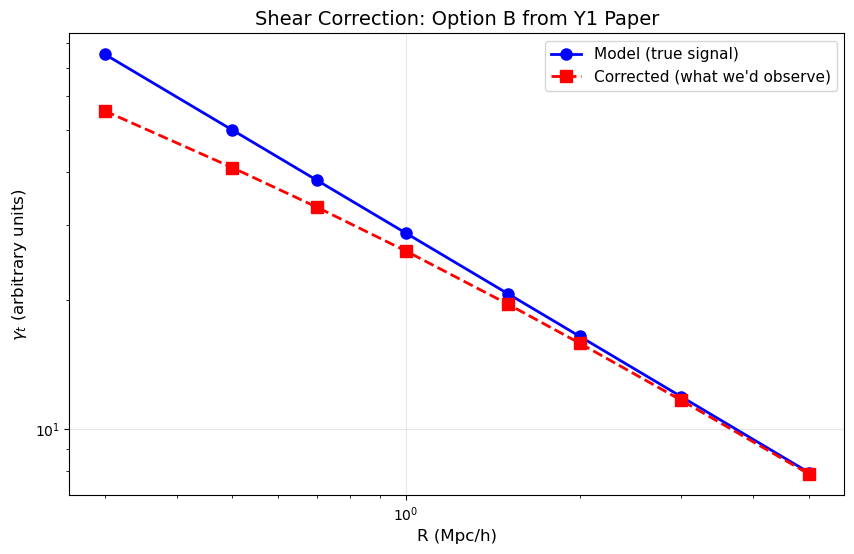

R        gamma_model    B(R)       gamma_corrected  reduction % 
------------------------------------------------------------
0.30     75.24          1.3564     55.4713          26.3        
0.50     50.00          1.2240     40.8509          18.3        
0.70     38.20          1.1559     33.0473          13.5        
1.00     28.72          1.1010     26.0836          9.2         
1.50     20.76          1.0579     19.6254          5.5         
2.00     16.49          1.0376     15.8955          3.6         
3.00     11.92          1.0196     11.6955          1.9         
5.00     7.92           1.0081     7.8607           0.8         


In [4]:
# Mock shear profile (typical NFW-like shape)
R = np.array([0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 5.0])
shear_model = 50 * (R / 0.5)**(-0.8)  # Arbitrary units, power-law shape

# Boost parameters
rs = 0.8
b0 = 0.4

# Compute boost and apply correction
B = boost_factor_model(R, rs, b0)
shear_corrected = shear_model / B

# Plot
plt.figure(figsize=(10, 6))
plt.plot(R, shear_model, 'b-o', lw=2, ms=8, label='Model (true signal)')
plt.plot(R, shear_corrected, 'r--s', lw=2, ms=8, label='Corrected (what we\'d observe)')
plt.xlabel('R (Mpc/h)', fontsize=12)
plt.ylabel(r'$\gamma_t$ (arbitrary units)', fontsize=12)
plt.title('Shear Correction: Option B from Y1 Paper', fontsize=14)
plt.xscale('log')
plt.yscale('log')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# Print table
print(f"{'R':<8} {'gamma_model':<14} {'B(R)':<10} {'gamma_corrected':<16} {'reduction %':<12}")
print("-" * 60)
for r, g, b, gc in zip(R, shear_model, B, shear_corrected):
    reduction = (1 - gc/g) * 100
    print(f"{r:<8.2f} {g:<14.2f} {b:<10.4f} {gc:<16.4f} {reduction:<12.1f}")

## 4. Test Bin Indexing

Verify the bin mapping matches the pipeline convention:
- 4 lambda bins (l=0,1,2,3)
- 3 redshift bins (z=0,1,2)
- Total: 12 bins

In [5]:
n_lambda_bins = 4
n_z_bins = 3

print(f"Bin scheme: {n_lambda_bins} lambda x {n_z_bins} z = {n_lambda_bins * n_z_bins} total bins")
print(f"\n{'ij':<6} {'l_bin':<8} {'z_bin':<8} {'param_suffix':<15}")
print("-" * 40)

for ij in range(n_lambda_bins * n_z_bins):
    l_bin = ij // n_z_bins
    z_bin = ij % n_z_bins
    suffix = f"l{l_bin}_z{z_bin}"
    print(f"{ij:<6} {l_bin:<8} {z_bin:<8} {suffix:<15}")

Bin scheme: 4 lambda x 3 z = 12 total bins

ij     l_bin    z_bin    param_suffix   
----------------------------------------
0      0        0        l0_z0          
1      0        1        l0_z1          
2      0        2        l0_z2          
3      1        0        l1_z0          
4      1        1        l1_z1          
5      1        2        l1_z2          
6      2        0        l2_z0          
7      2        1        l2_z1          
8      2        2        l2_z2          
9      3        0        l3_z0          
10     3        1        l3_z1          
11     3        2        l3_z2          
